In [ ]:
# Function definitions and imports for batch processing all folders
import os
import re
import cv2
import numpy as np
from datetime import datetime, timedelta
from scipy.signal import find_peaks, peak_widths
from scipy.ndimage import gaussian_filter1d
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import glob
import pandas as pd

# Parameters (CHANGE)
parent_folder = "/Volumes/D06V1/D06V1/OSC_Videos/2026ab/"
# parent_folder = "/Volumes/Untitled/"
peak_threshold = 3.5  # V, for peak detection in Vpp signal
profile_threshold_stored = 1000  # Threshold for stored region
profile_threshold_inj = 1000     # Threshold for inj region
# max_files = 2  # Set to a number to limit files per folder, or None to process all
max_files = None  # Uncomment to process all files

# Parameters (DO NOT CHANGE)
grid_height_px_stored = 3.4/5.56*400/10/1.05  # stored region (distorted)
grid_height_px_inj = 3.95/5.56*400/10         # inj region
inj_time_px = 30
v_div = 2.0
fps = 20.0

def extract_datetime_from_filename(filename):
    """Extract YYYYMMDD_HHMMSS from filename."""
    match = re.search(r"(\d{8})_(\d{6})", filename)
    if not match:
        return None
    date_part, time_part = match.groups()
    return datetime.strptime(date_part + time_part, "%Y%m%d%H%M%S")

def _vpp_from_mask(mask_part, threshold, volts_per_pixel):
    """Compute Vpp from mask using profile + threshold method."""
    vertical_profile = np.sum(mask_part, axis=1)
    smooth_profile = gaussian_filter1d(vertical_profile.astype(float), sigma=2.0)
    above_threshold = smooth_profile > threshold
    if np.any(above_threshold):
        threshold_positions = np.where(above_threshold)[0]
        y_min = threshold_positions[0]
        y_max = threshold_positions[-1]
        peak_width_pixels = y_max - y_min
        return peak_width_pixels * volts_per_pixel
    return np.nan

def compute_vpp_series_for_file(file_path, v_div=2.0, fps=20.0, threshold_stored=1000, threshold_inj=1000, split_x=None, grid_height_px_stored=3.4/5.56*400/10/1.05, grid_height_px_inj=3.95/5.56*400/10):
    """Compute Vpp for CH3 (red trace) per frame for both stored and inj regions."""
    cap = cv2.VideoCapture(file_path)
    volts_per_pixel_stored = v_div / grid_height_px_stored
    volts_per_pixel_inj = v_div / grid_height_px_inj

    vpp_stored_series = []
    vpp_inj_series = []

    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break

        height, width, _ = frame.shape
        roi = frame[int(height * 0.2):int(height * 0.8), int(width * 0.1):int(width * 0.9)]

        hsv = cv2.cvtColor(roi, cv2.COLOR_BGR2HSV)
        mask1 = cv2.inRange(hsv, np.array([0, 100, 100]), np.array([10, 255, 255]))
        mask2 = cv2.inRange(hsv, np.array([160, 100, 100]), np.array([180, 255, 255]))
        red_mask = cv2.bitwise_or(mask1, mask2)

        split_idx = max(0, min(int(split_x), red_mask.shape[1] - 1))
        red_mask_stored = red_mask[:, :split_idx + 1]
        red_mask_inj = red_mask[:, split_idx + 1:]

        if red_mask_stored.shape[1] > 0:
            vpp_stored_series.append(_vpp_from_mask(red_mask_stored, threshold_stored, volts_per_pixel_stored))
        else:
            vpp_stored_series.append(np.nan)

        if red_mask_inj.shape[1] > 0:
            vpp_inj_series.append(_vpp_from_mask(red_mask_inj, threshold_inj, volts_per_pixel_inj))
        else:
            vpp_inj_series.append(np.nan)

    cap.release()
    time_series_sec = np.arange(len(vpp_stored_series)) / fps
    return time_series_sec, np.array(vpp_stored_series), np.array(vpp_inj_series)

Found 10 folder(s) in: /Volumes/Untitled/

[1/10] Processing folder: 20260225
Found 288 total video file(s)
Processing all 288 file(s)

[1/288] 20260225_000000_n.mkv
  ✓ Vpp range: 1.196 - 1.971 V

[2/288] 20260225_000500_n.mkv
  ✓ Vpp range: 1.196 - 1.900 V

[3/288] 20260225_001000_n.mkv
  ✓ Vpp range: 1.267 - 1.900 V

[4/288] 20260225_001500_n.mkv
  ✓ Vpp range: 1.196 - 1.900 V

[5/288] 20260225_002000_n.mkv
  ✓ Vpp range: 1.196 - 1.900 V

[6/288] 20260225_002500_n.mkv
  ✓ Vpp range: 1.267 - 1.900 V

[7/288] 20260225_003000_n.mkv
  ✓ Vpp range: 1.267 - 1.971 V

[8/288] 20260225_003500_n.mkv
  ✓ Vpp range: 1.267 - 1.971 V

[9/288] 20260225_004000_n.mkv
  ✓ Vpp range: 1.196 - 1.971 V

[10/288] 20260225_004500_n.mkv
  ✓ Vpp range: 1.267 - 1.971 V

[11/288] 20260225_005000_n.mkv
  ✓ Vpp range: 1.267 - 1.971 V

[12/288] 20260225_005500_n.mkv
  ✓ Vpp range: 1.267 - 1.900 V

[13/288] 20260225_010000_n.mkv
  ✓ Vpp range: 1.267 - 1.900 V

[14/288] 20260225_010500_n.mkv
  ✓ Vpp range: 1.196 - 

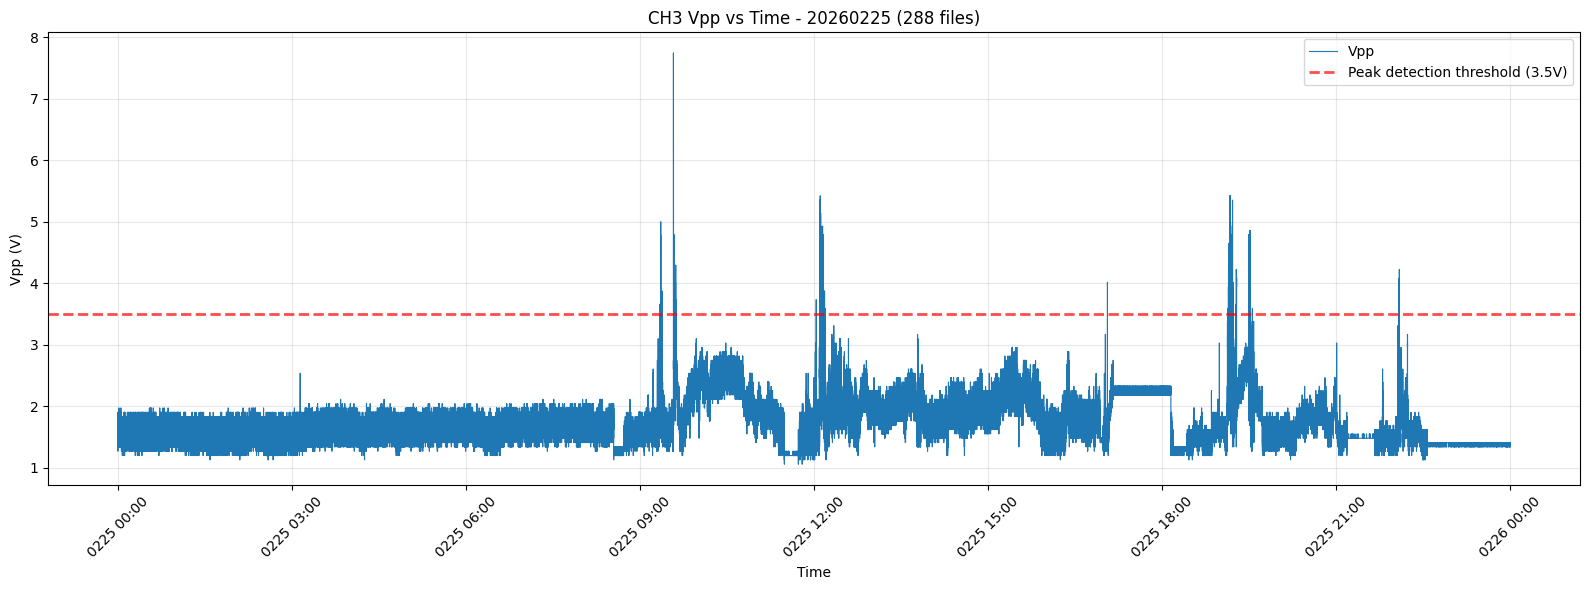


Found 218 peak(s) with Vpp > 3.5 V

PEAK SUMMARY
Peak 1: 2026-02-25 09:20:42 → Vpp = 3.6597 V
Peak 2: 2026-02-25 09:21:18 → Vpp = 4.7858 V
Peak 3: 2026-02-25 09:21:26 → Vpp = 4.9970 V
Peak 4: 2026-02-25 09:22:48 → Vpp = 3.8709 V
Peak 5: 2026-02-25 09:34:34 → Vpp = 7.7418 V
Peak 6: 2026-02-25 09:34:35 → Vpp = 4.7154 V
Peak 7: 2026-02-25 09:34:39 → Vpp = 3.9413 V
Peak 8: 2026-02-25 09:34:41 → Vpp = 3.6597 V
Peak 9: 2026-02-25 09:34:56 → Vpp = 4.7858 V
Peak 10: 2026-02-25 09:34:58 → Vpp = 4.0116 V
Peak 11: 2026-02-25 09:34:59 → Vpp = 4.0116 V
Peak 12: 2026-02-25 09:35:00 → Vpp = 3.5894 V
Peak 13: 2026-02-25 09:35:01 → Vpp = 4.6451 V
Peak 14: 2026-02-25 09:35:03 → Vpp = 4.4339 V
Peak 15: 2026-02-25 09:35:07 → Vpp = 4.7858 V
Peak 16: 2026-02-25 09:35:08 → Vpp = 4.1524 V
Peak 17: 2026-02-25 09:35:09 → Vpp = 3.9413 V
Peak 18: 2026-02-25 09:36:45 → Vpp = 4.0116 V
Peak 19: 2026-02-25 09:36:50 → Vpp = 3.6597 V
Peak 20: 2026-02-25 09:36:51 → Vpp = 3.5894 V
Peak 21: 2026-02-25 09:36:53 → Vpp = 3.

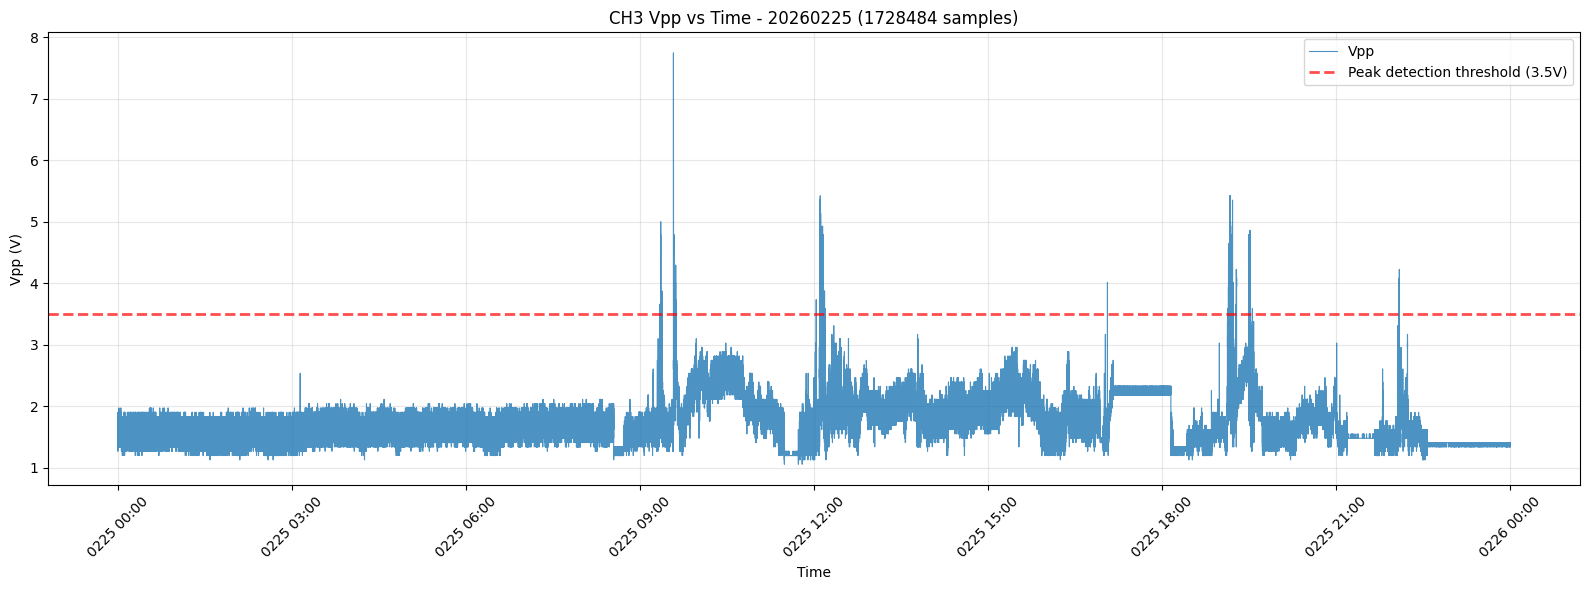

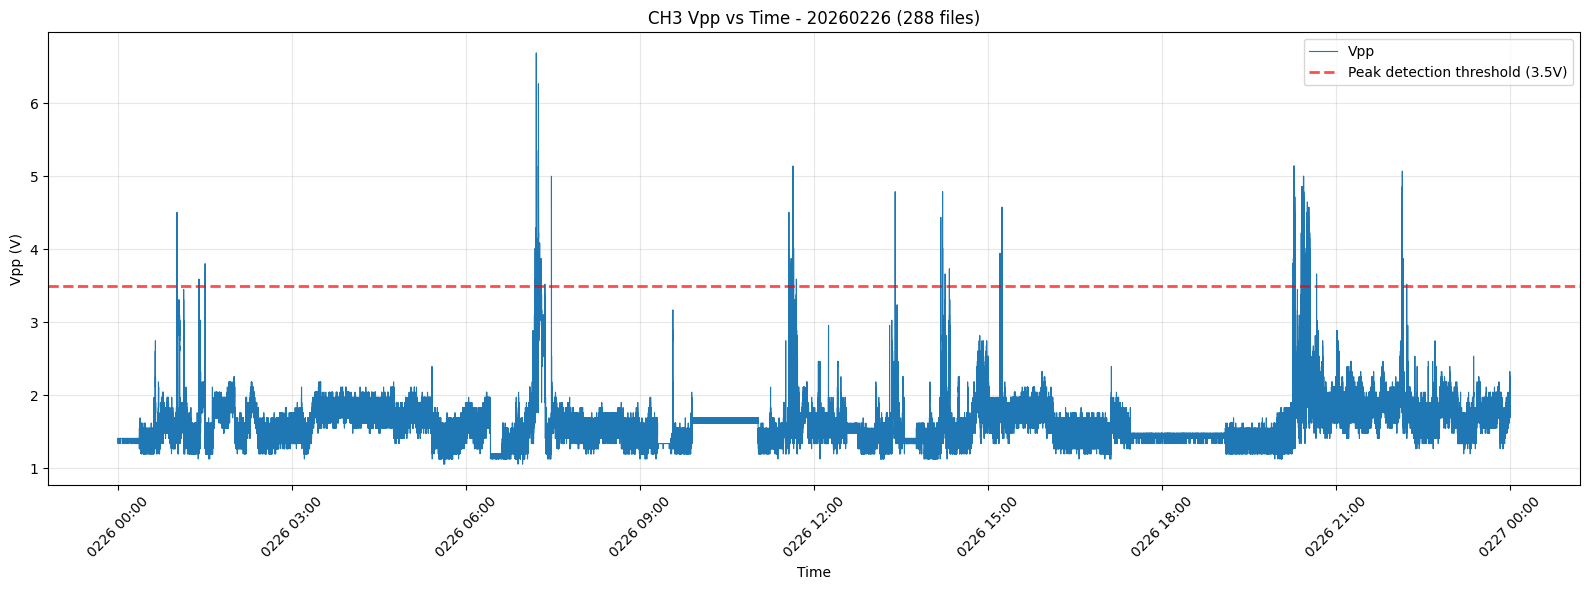


Found 342 peak(s) with Vpp > 3.5 V

PEAK SUMMARY
Peak 1: 2026-02-26 01:01:11 → Vpp = 4.5043 V
Peak 2: 2026-02-26 01:23:58 → Vpp = 3.5894 V
Peak 3: 2026-02-26 01:30:16 → Vpp = 3.6597 V
Peak 4: 2026-02-26 01:30:17 → Vpp = 3.8005 V
Peak 5: 2026-02-26 07:11:02 → Vpp = 3.5894 V
Peak 6: 2026-02-26 07:11:05 → Vpp = 3.5190 V
Peak 7: 2026-02-26 07:11:31 → Vpp = 4.0116 V
Peak 8: 2026-02-26 07:12:31 → Vpp = 4.0116 V
Peak 9: 2026-02-26 07:12:38 → Vpp = 4.0820 V
Peak 10: 2026-02-26 07:12:39 → Vpp = 4.2932 V
Peak 11: 2026-02-26 07:12:42 → Vpp = 3.5894 V
Peak 12: 2026-02-26 07:12:44 → Vpp = 6.6861 V
Peak 13: 2026-02-26 07:13:07 → Vpp = 4.0820 V
Peak 14: 2026-02-26 07:13:08 → Vpp = 4.0820 V
Peak 15: 2026-02-26 07:13:11 → Vpp = 4.1524 V
Peak 16: 2026-02-26 07:14:51 → Vpp = 4.1524 V
Peak 17: 2026-02-26 07:14:52 → Vpp = 5.1377 V
Peak 18: 2026-02-26 07:14:55 → Vpp = 5.3489 V
Peak 19: 2026-02-26 07:14:56 → Vpp = 5.1377 V
Peak 20: 2026-02-26 07:14:58 → Vpp = 6.2638 V
Peak 21: 2026-02-26 07:14:59 → Vpp = 5.

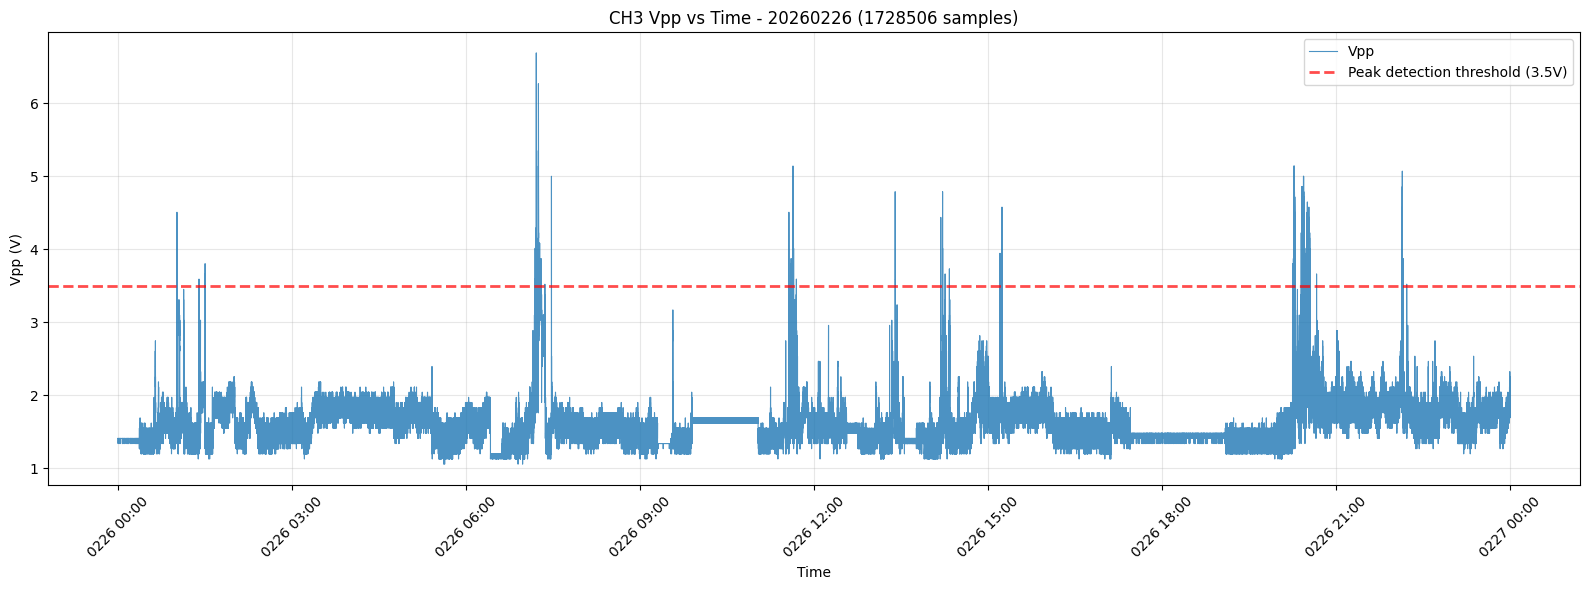

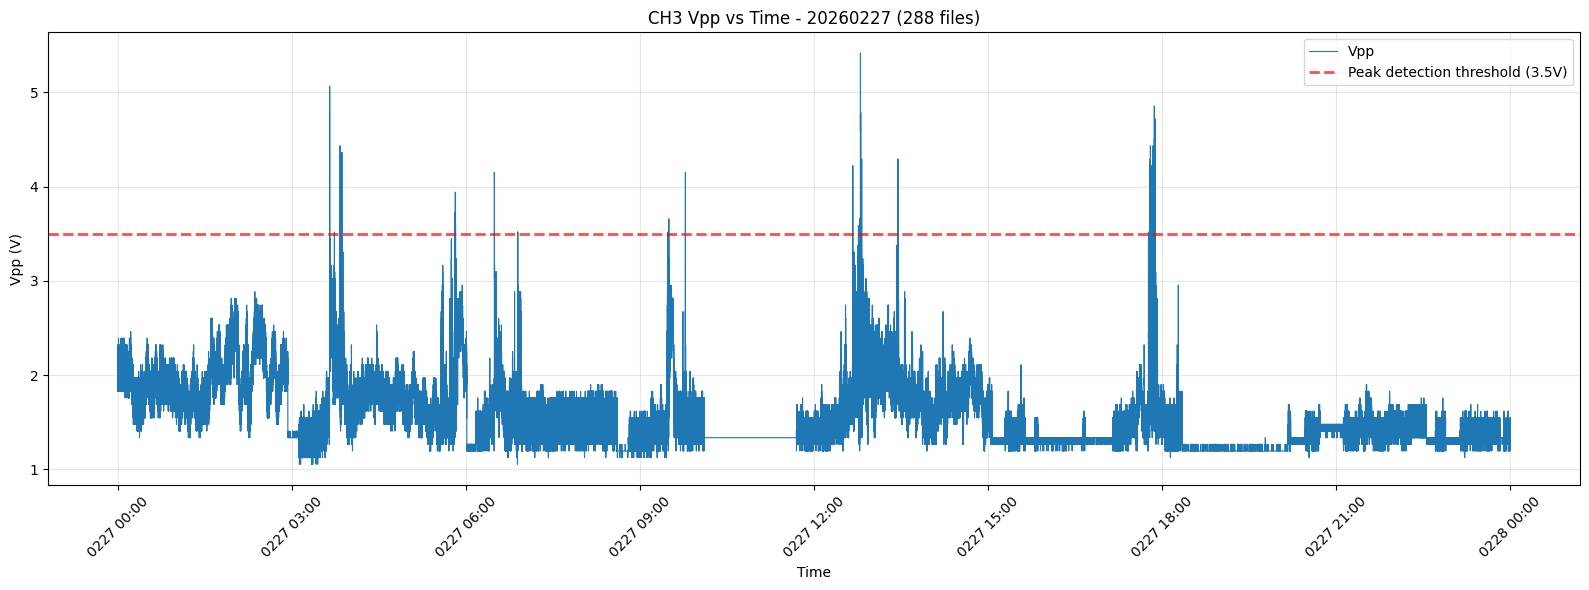


Found 143 peak(s) with Vpp > 3.5 V

PEAK SUMMARY
Peak 1: 2026-02-27 03:39:06 → Vpp = 5.0673 V
Peak 2: 2026-02-27 03:39:07 → Vpp = 5.0673 V
Peak 3: 2026-02-27 03:39:08 → Vpp = 4.9970 V
Peak 4: 2026-02-27 03:39:09 → Vpp = 4.9970 V
Peak 5: 2026-02-27 03:39:11 → Vpp = 4.2228 V
Peak 6: 2026-02-27 03:39:12 → Vpp = 4.0820 V
Peak 7: 2026-02-27 03:44:00 → Vpp = 3.5190 V
Peak 8: 2026-02-27 03:49:52 → Vpp = 4.4339 V
Peak 9: 2026-02-27 03:50:00 → Vpp = 3.5894 V
Peak 10: 2026-02-27 03:51:45 → Vpp = 4.3635 V
Peak 11: 2026-02-27 03:51:46 → Vpp = 3.7301 V
Peak 12: 2026-02-27 03:51:48 → Vpp = 3.5894 V
Peak 13: 2026-02-27 05:48:54 → Vpp = 3.5190 V
Peak 14: 2026-02-27 05:48:56 → Vpp = 3.7301 V
Peak 15: 2026-02-27 05:48:57 → Vpp = 3.5894 V
Peak 16: 2026-02-27 05:48:58 → Vpp = 3.7301 V
Peak 17: 2026-02-27 05:49:02 → Vpp = 3.9413 V
Peak 18: 2026-02-27 05:49:03 → Vpp = 3.8709 V
Peak 19: 2026-02-27 05:49:05 → Vpp = 3.5894 V
Peak 20: 2026-02-27 05:49:07 → Vpp = 3.6597 V
Peak 21: 2026-02-27 05:49:15 → Vpp = 3.

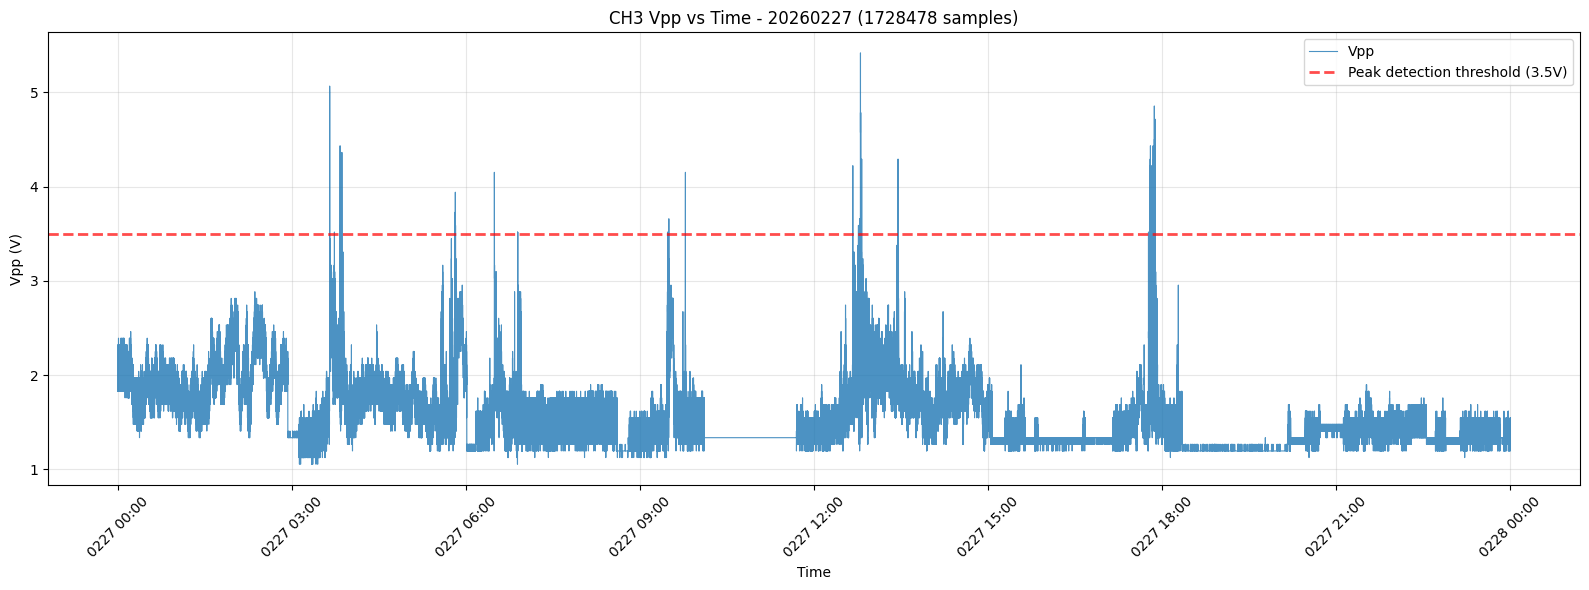

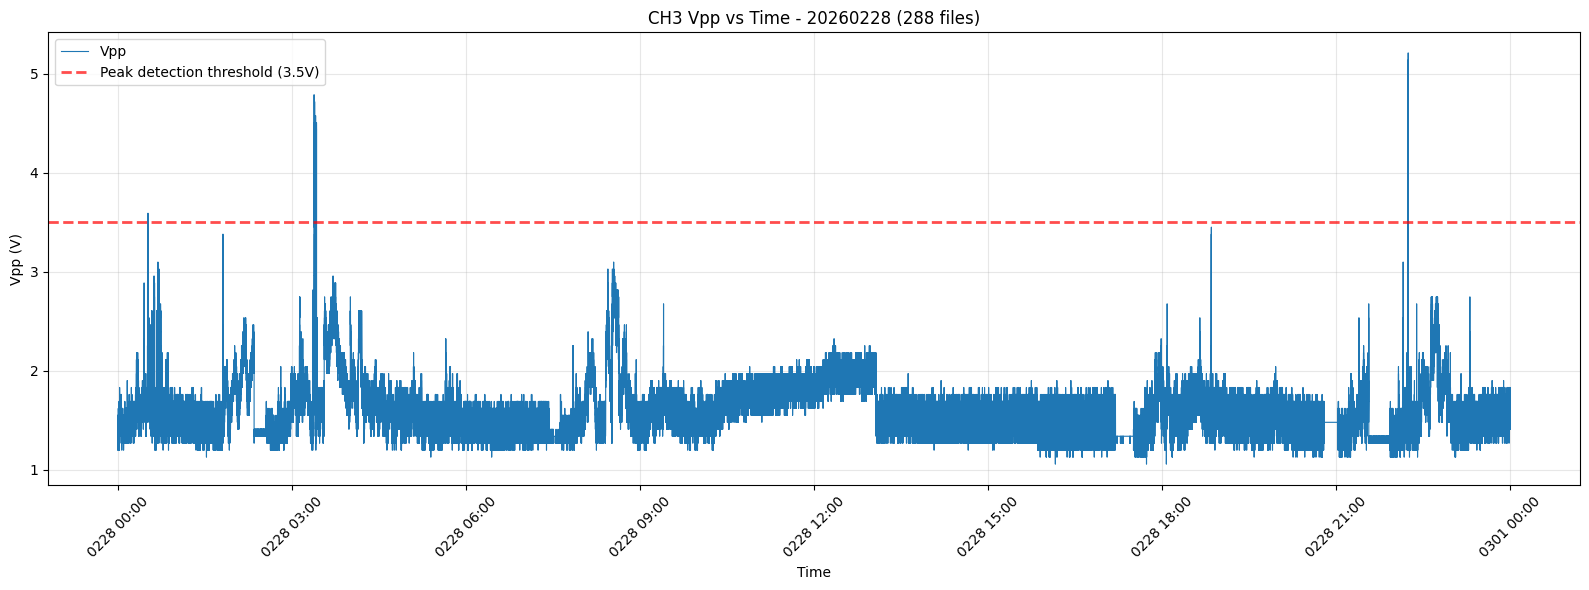


Found 40 peak(s) with Vpp > 3.5 V

PEAK SUMMARY
Peak 1: 2026-02-28 00:31:13 → Vpp = 3.5894 V
Peak 2: 2026-02-28 03:22:57 → Vpp = 4.5043 V
Peak 3: 2026-02-28 03:22:59 → Vpp = 4.7858 V
Peak 4: 2026-02-28 03:23:04 → Vpp = 4.7154 V
Peak 5: 2026-02-28 03:23:05 → Vpp = 4.2932 V
Peak 6: 2026-02-28 03:23:06 → Vpp = 4.2932 V
Peak 7: 2026-02-28 03:23:10 → Vpp = 4.2932 V
Peak 8: 2026-02-28 03:23:12 → Vpp = 4.1524 V
Peak 9: 2026-02-28 03:23:13 → Vpp = 3.9413 V
Peak 10: 2026-02-28 03:23:18 → Vpp = 3.9413 V
Peak 11: 2026-02-28 03:23:25 → Vpp = 3.5190 V
Peak 12: 2026-02-28 03:23:26 → Vpp = 3.6597 V
Peak 13: 2026-02-28 03:23:32 → Vpp = 4.1524 V
Peak 14: 2026-02-28 03:23:33 → Vpp = 4.7154 V
Peak 15: 2026-02-28 03:23:38 → Vpp = 4.5043 V
Peak 16: 2026-02-28 03:23:39 → Vpp = 4.4339 V
Peak 17: 2026-02-28 03:23:40 → Vpp = 4.3635 V
Peak 18: 2026-02-28 03:23:45 → Vpp = 4.2932 V
Peak 19: 2026-02-28 03:23:47 → Vpp = 4.2228 V
Peak 20: 2026-02-28 03:23:50 → Vpp = 4.1524 V
Peak 21: 2026-02-28 03:23:54 → Vpp = 4.0

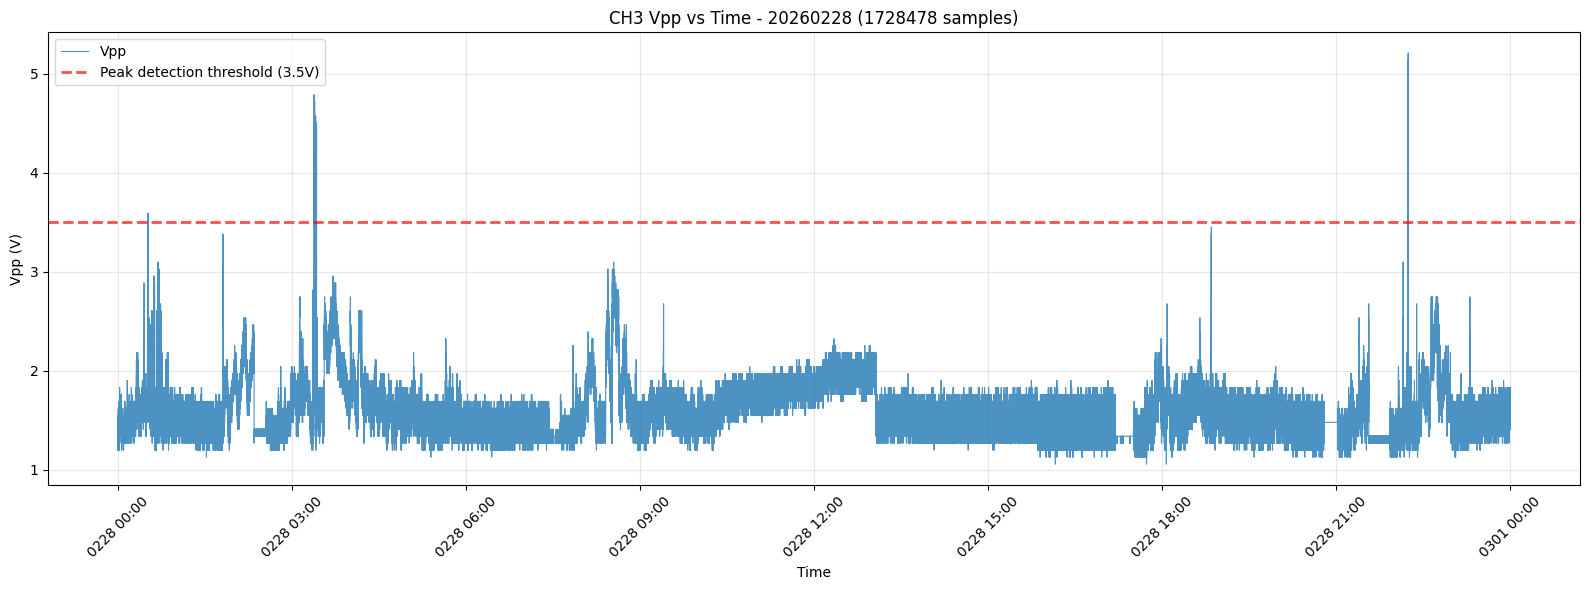

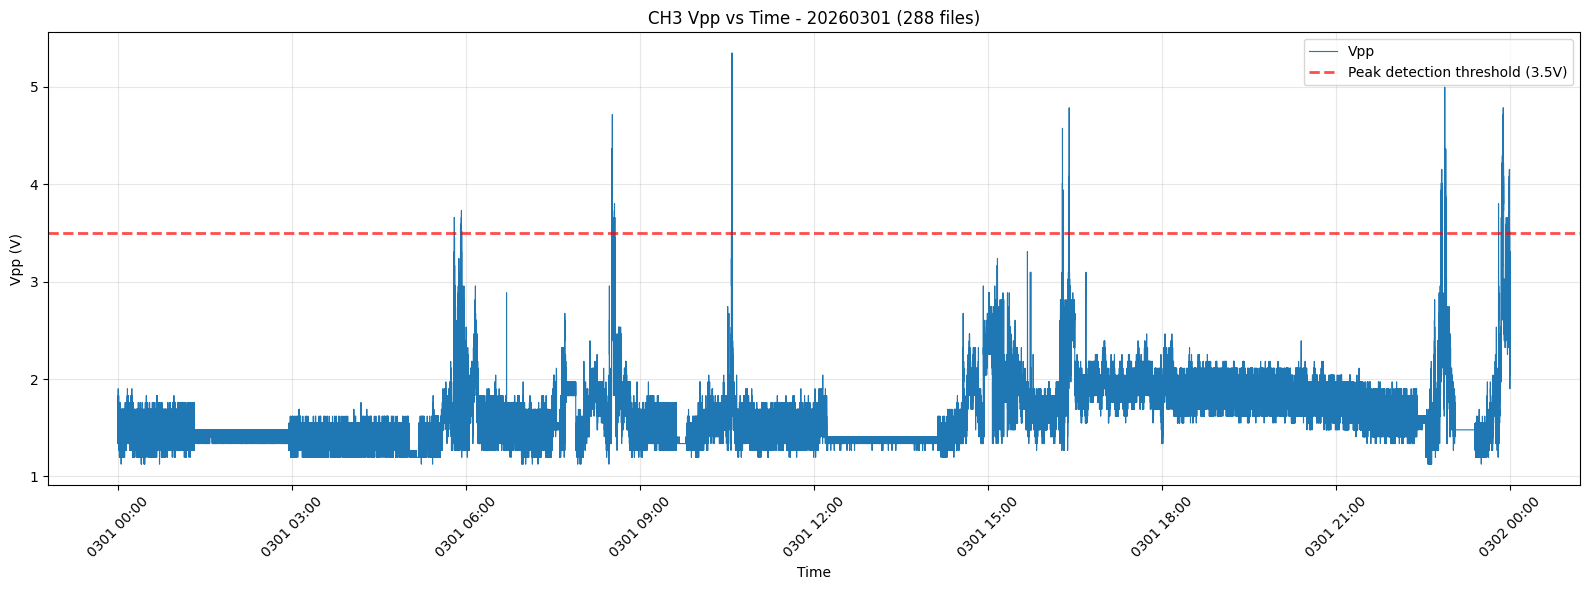


Found 199 peak(s) with Vpp > 3.5 V

PEAK SUMMARY
Peak 1: 2026-03-01 05:47:59 → Vpp = 3.6597 V
Peak 2: 2026-03-01 05:54:25 → Vpp = 3.5894 V
Peak 3: 2026-03-01 05:55:15 → Vpp = 3.6597 V
Peak 4: 2026-03-01 05:55:21 → Vpp = 3.7301 V
Peak 5: 2026-03-01 05:55:37 → Vpp = 3.5190 V
Peak 6: 2026-03-01 08:30:39 → Vpp = 4.2932 V
Peak 7: 2026-03-01 08:30:44 → Vpp = 4.2228 V
Peak 8: 2026-03-01 08:30:45 → Vpp = 4.3635 V
Peak 9: 2026-03-01 08:30:47 → Vpp = 4.1524 V
Peak 10: 2026-03-01 08:30:49 → Vpp = 4.0116 V
Peak 11: 2026-03-01 08:30:51 → Vpp = 4.1524 V
Peak 12: 2026-03-01 08:30:52 → Vpp = 4.0116 V
Peak 13: 2026-03-01 08:30:53 → Vpp = 3.8709 V
Peak 14: 2026-03-01 08:30:54 → Vpp = 3.9413 V
Peak 15: 2026-03-01 08:30:56 → Vpp = 3.9413 V
Peak 16: 2026-03-01 08:30:58 → Vpp = 4.1524 V
Peak 17: 2026-03-01 08:30:59 → Vpp = 4.0116 V
Peak 18: 2026-03-01 08:31:00 → Vpp = 3.5894 V
Peak 19: 2026-03-01 08:31:05 → Vpp = 3.5190 V
Peak 20: 2026-03-01 08:31:15 → Vpp = 3.5190 V
Peak 21: 2026-03-01 08:31:16 → Vpp = 3.

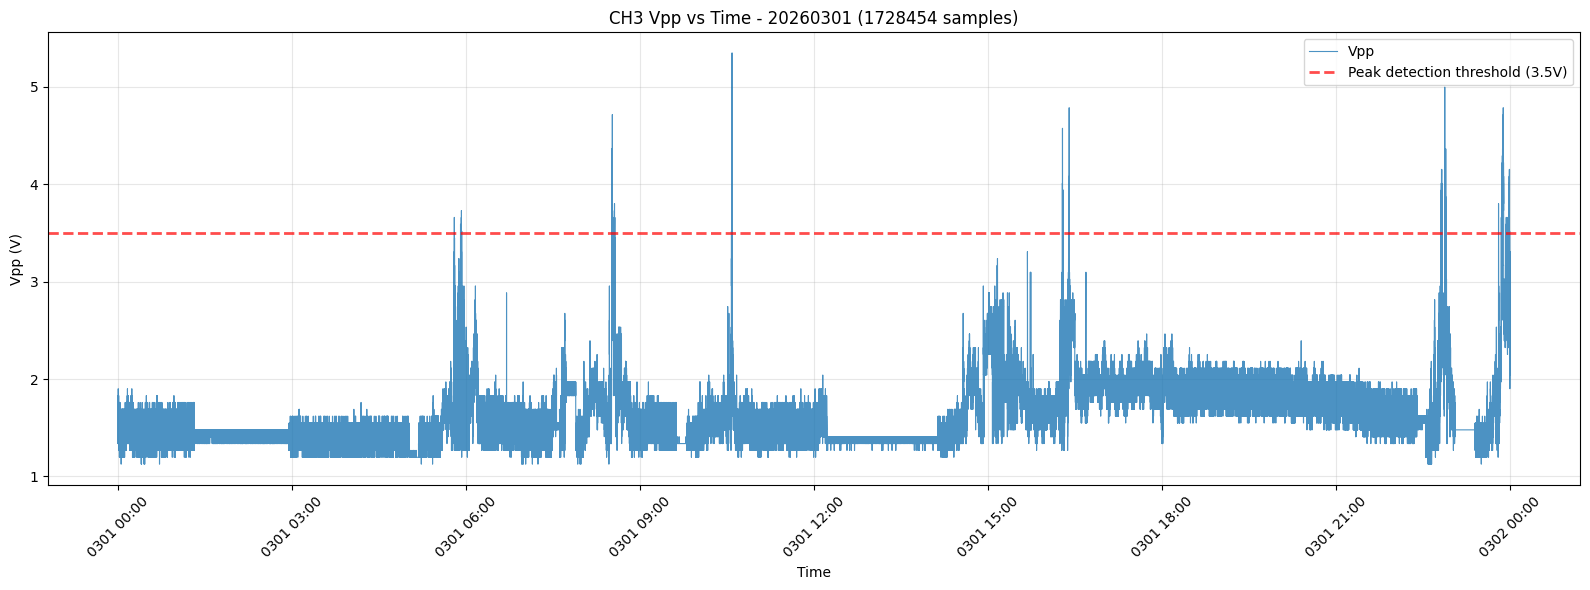

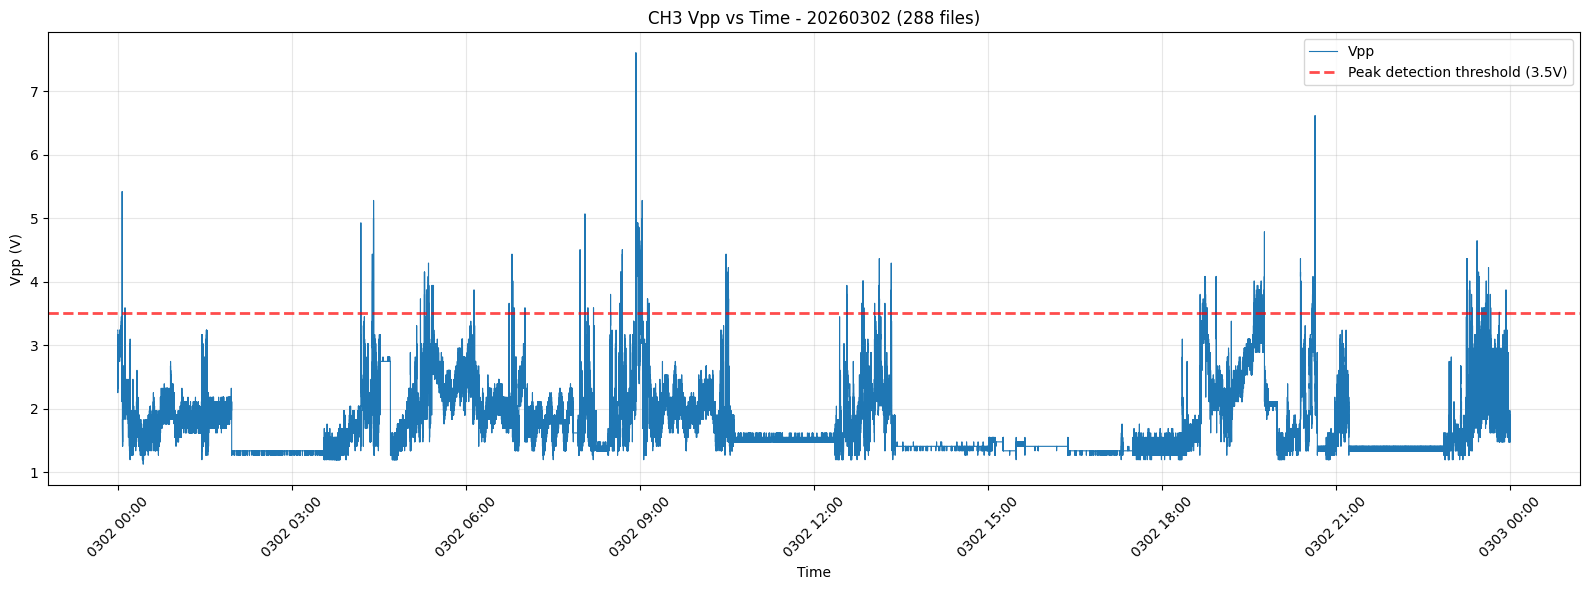


Found 724 peak(s) with Vpp > 3.5 V

PEAK SUMMARY
Peak 1: 2026-03-02 00:04:30 → Vpp = 5.4192 V
Peak 2: 2026-03-02 00:07:28 → Vpp = 3.5894 V
Peak 3: 2026-03-02 04:11:21 → Vpp = 4.8562 V
Peak 4: 2026-03-02 04:11:22 → Vpp = 4.9266 V
Peak 5: 2026-03-02 04:11:23 → Vpp = 4.2932 V
Peak 6: 2026-03-02 04:23:11 → Vpp = 4.4339 V
Peak 7: 2026-03-02 04:23:22 → Vpp = 4.0116 V
Peak 8: 2026-03-02 04:23:26 → Vpp = 4.2932 V
Peak 9: 2026-03-02 04:24:03 → Vpp = 3.7301 V
Peak 10: 2026-03-02 04:24:20 → Vpp = 4.4339 V
Peak 11: 2026-03-02 04:24:24 → Vpp = 4.9970 V
Peak 12: 2026-03-02 04:24:29 → Vpp = 5.2785 V
Peak 13: 2026-03-02 04:24:33 → Vpp = 5.1377 V
Peak 14: 2026-03-02 04:24:34 → Vpp = 5.1377 V
Peak 15: 2026-03-02 04:24:36 → Vpp = 3.9413 V
Peak 16: 2026-03-02 04:24:37 → Vpp = 3.8709 V
Peak 17: 2026-03-02 04:24:40 → Vpp = 3.9413 V
Peak 18: 2026-03-02 05:12:58 → Vpp = 3.7301 V
Peak 19: 2026-03-02 05:17:01 → Vpp = 4.1524 V
Peak 20: 2026-03-02 05:17:03 → Vpp = 4.1524 V
Peak 21: 2026-03-02 05:17:04 → Vpp = 3.

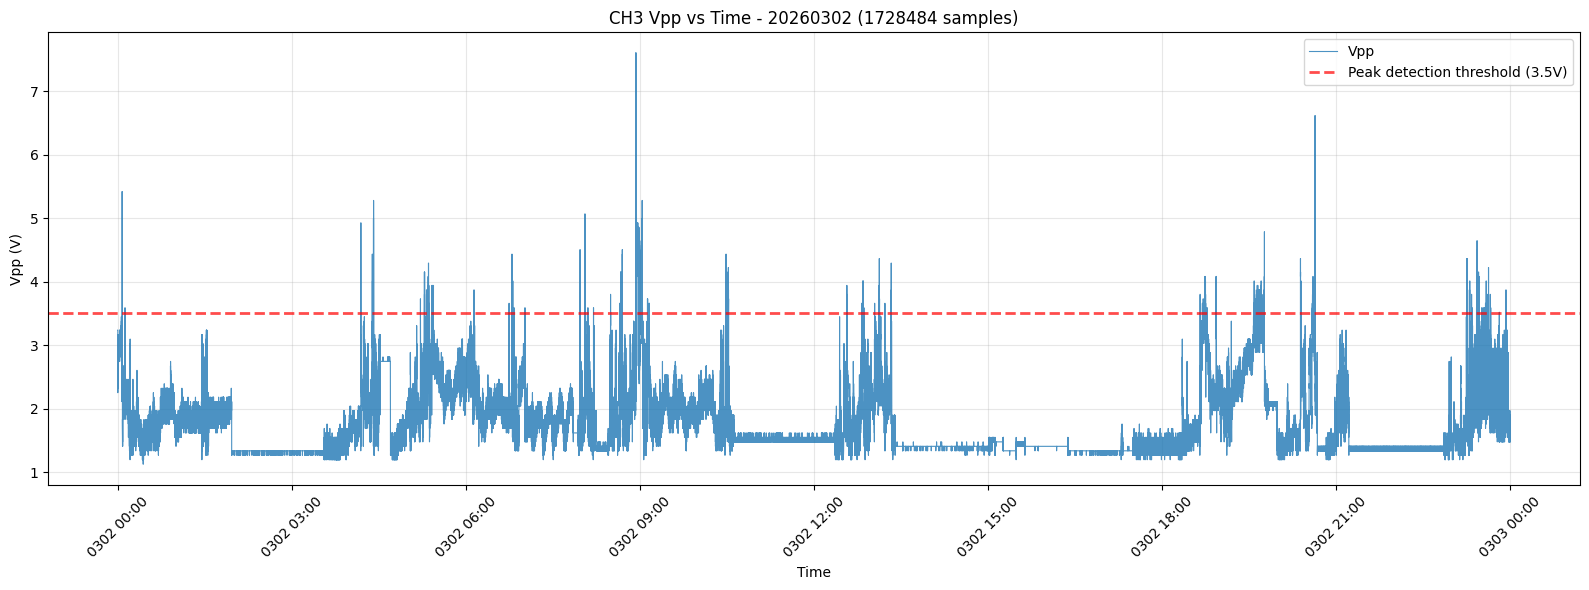

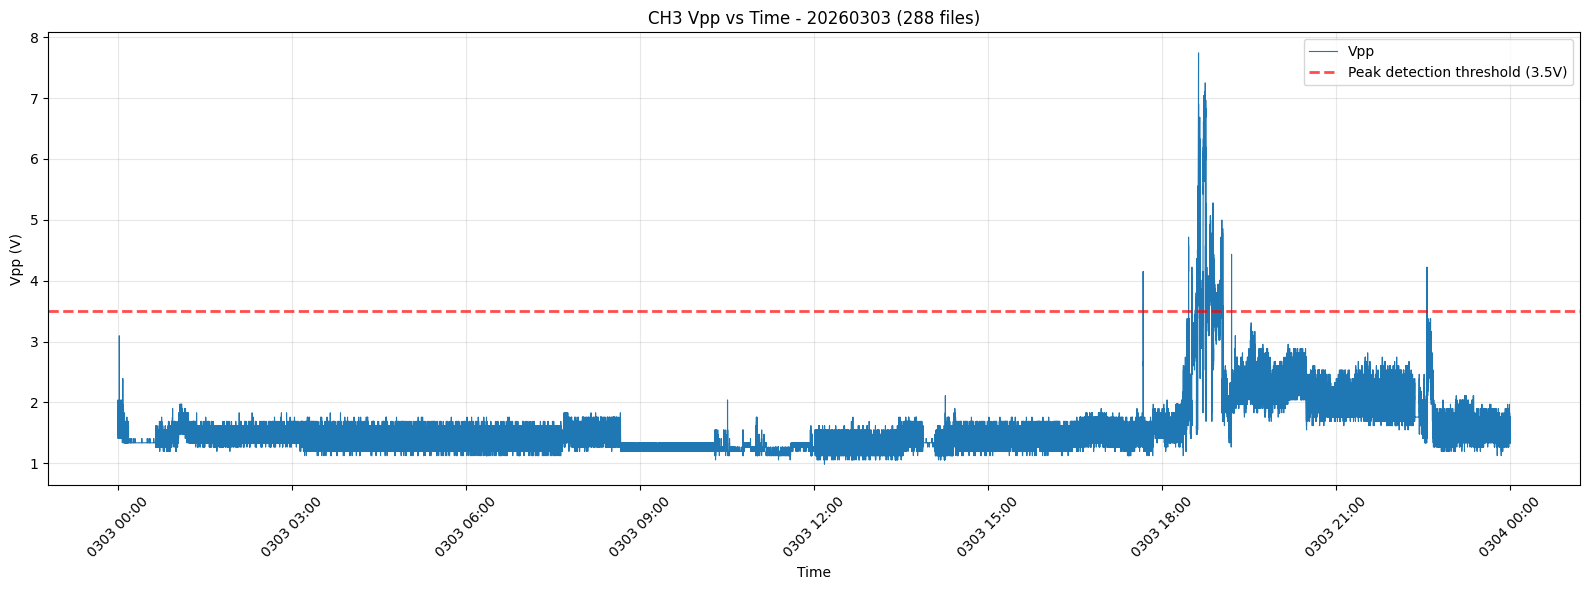


Found 659 peak(s) with Vpp > 3.5 V

PEAK SUMMARY
Peak 1: 2026-03-03 17:40:14 → Vpp = 4.1524 V
Peak 2: 2026-03-03 18:27:10 → Vpp = 3.5894 V
Peak 3: 2026-03-03 18:27:14 → Vpp = 4.7154 V
Peak 4: 2026-03-03 18:27:15 → Vpp = 4.1524 V
Peak 5: 2026-03-03 18:27:16 → Vpp = 3.5894 V
Peak 6: 2026-03-03 18:27:18 → Vpp = 3.6597 V
Peak 7: 2026-03-03 18:27:19 → Vpp = 3.7301 V
Peak 8: 2026-03-03 18:30:33 → Vpp = 4.0820 V
Peak 9: 2026-03-03 18:30:40 → Vpp = 4.0116 V
Peak 10: 2026-03-03 18:30:41 → Vpp = 4.2228 V
Peak 11: 2026-03-03 18:30:44 → Vpp = 3.6597 V
Peak 12: 2026-03-03 18:30:46 → Vpp = 3.8005 V
Peak 13: 2026-03-03 18:30:53 → Vpp = 3.5190 V
Peak 14: 2026-03-03 18:30:55 → Vpp = 3.5190 V
Peak 15: 2026-03-03 18:34:08 → Vpp = 3.5190 V
Peak 16: 2026-03-03 18:34:37 → Vpp = 3.5190 V
Peak 17: 2026-03-03 18:34:39 → Vpp = 3.5190 V
Peak 18: 2026-03-03 18:34:46 → Vpp = 3.6597 V
Peak 19: 2026-03-03 18:34:50 → Vpp = 3.5894 V
Peak 20: 2026-03-03 18:34:53 → Vpp = 3.6597 V
Peak 21: 2026-03-03 18:34:57 → Vpp = 3.

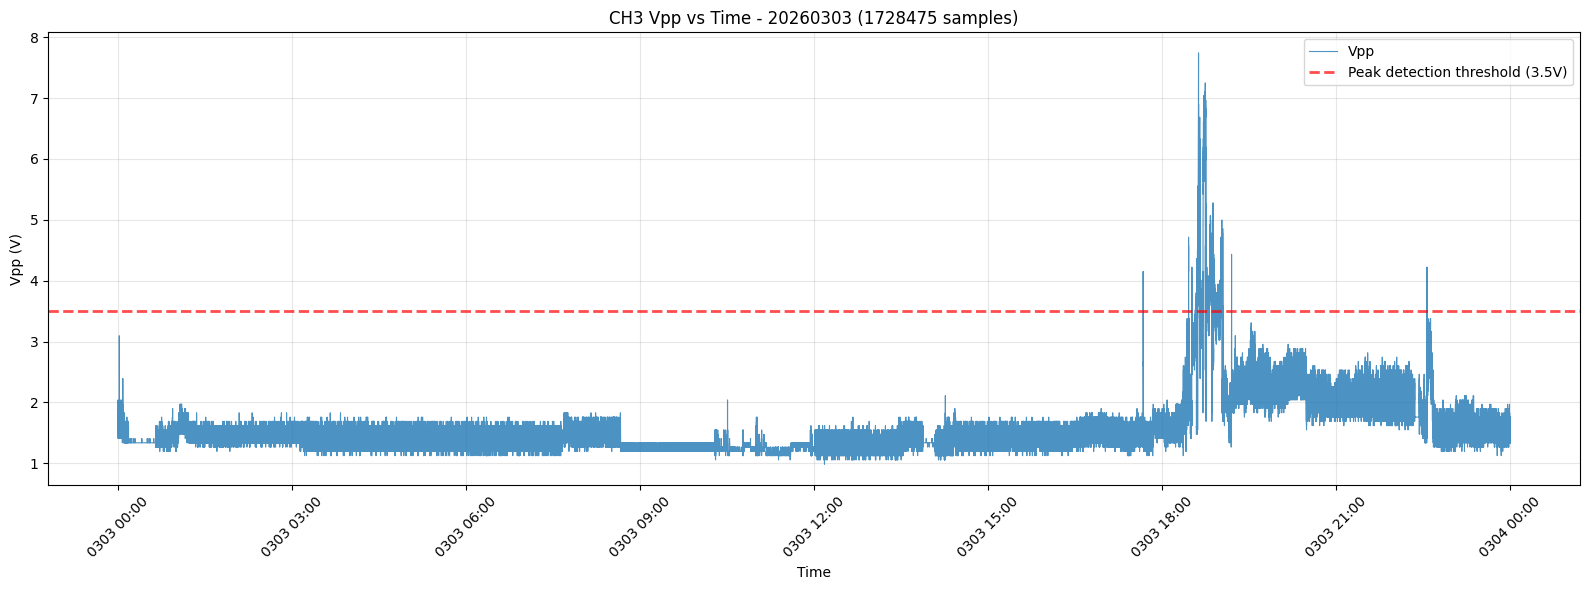

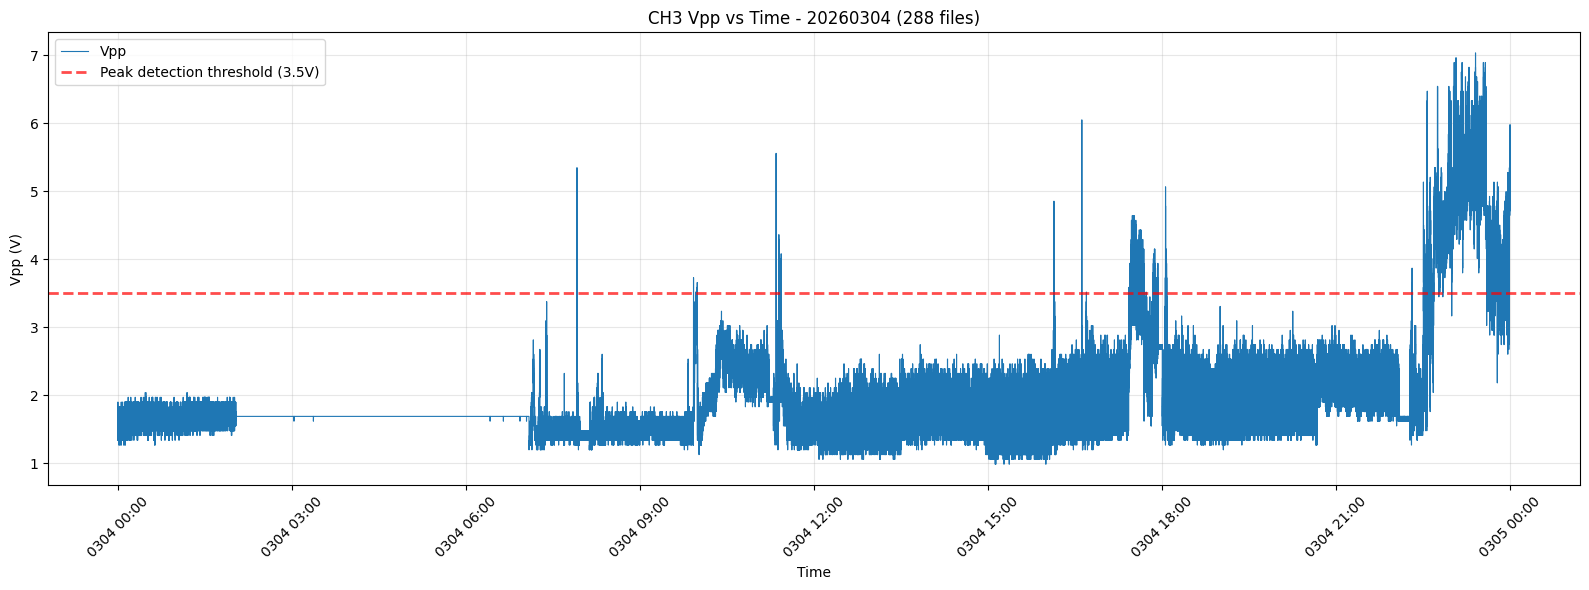


Found 2917 peak(s) with Vpp > 3.5 V

PEAK SUMMARY
Peak 1: 2026-03-04 07:54:46 → Vpp = 4.3635 V
Peak 2: 2026-03-04 07:54:47 → Vpp = 4.5747 V
Peak 3: 2026-03-04 07:54:49 → Vpp = 5.3489 V
Peak 4: 2026-03-04 07:54:50 → Vpp = 4.3635 V
Peak 5: 2026-03-04 07:54:52 → Vpp = 3.5894 V
Peak 6: 2026-03-04 07:54:59 → Vpp = 3.6597 V
Peak 7: 2026-03-04 07:55:11 → Vpp = 4.2228 V
Peak 8: 2026-03-04 09:55:20 → Vpp = 3.7301 V
Peak 9: 2026-03-04 09:57:29 → Vpp = 3.5190 V
Peak 10: 2026-03-04 09:58:24 → Vpp = 3.5190 V
Peak 11: 2026-03-04 09:59:06 → Vpp = 3.5894 V
Peak 12: 2026-03-04 09:59:08 → Vpp = 3.5894 V
Peak 13: 2026-03-04 09:59:12 → Vpp = 3.6597 V
Peak 14: 2026-03-04 11:20:42 → Vpp = 5.5600 V
Peak 15: 2026-03-04 11:20:45 → Vpp = 4.3635 V
Peak 16: 2026-03-04 11:20:47 → Vpp = 4.2932 V
Peak 17: 2026-03-04 11:23:19 → Vpp = 4.0116 V
Peak 18: 2026-03-04 11:23:20 → Vpp = 3.7301 V
Peak 19: 2026-03-04 11:23:25 → Vpp = 3.8709 V
Peak 20: 2026-03-04 11:23:27 → Vpp = 3.9413 V
Peak 21: 2026-03-04 11:23:34 → Vpp = 4

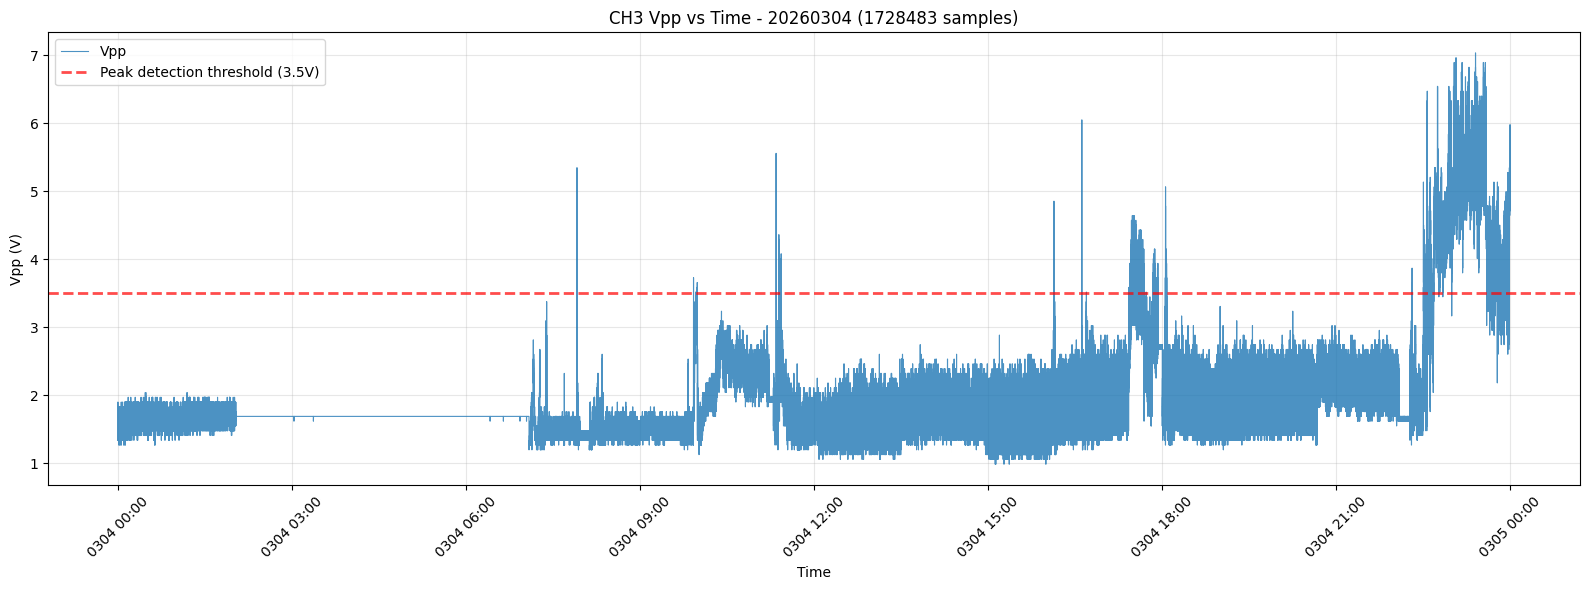

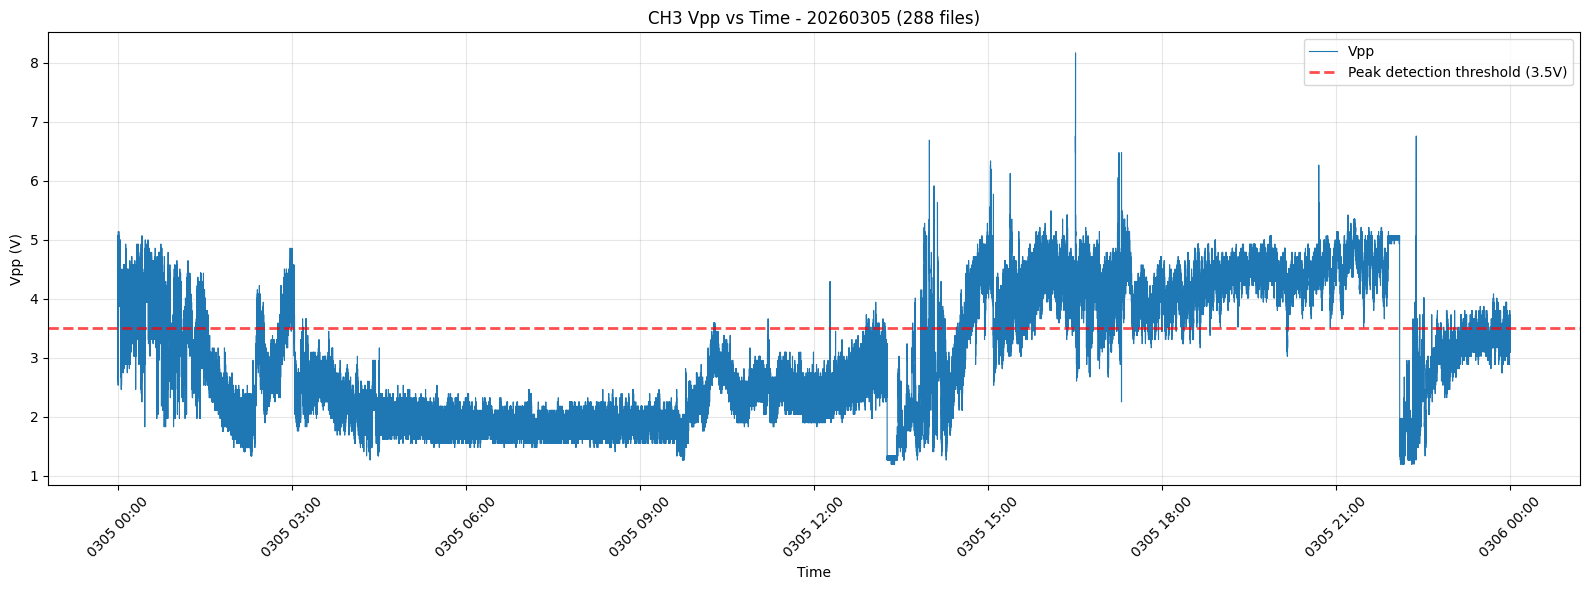


Found 17070 peak(s) with Vpp > 3.5 V

PEAK SUMMARY
Peak 1: 2026-03-05 00:00:00 → Vpp = 4.9970 V
Peak 2: 2026-03-05 00:00:01 → Vpp = 4.9970 V
Peak 3: 2026-03-05 00:00:04 → Vpp = 4.7154 V
Peak 4: 2026-03-05 00:00:05 → Vpp = 3.5190 V
Peak 5: 2026-03-05 00:00:06 → Vpp = 3.5894 V
Peak 6: 2026-03-05 00:00:11 → Vpp = 3.9413 V
Peak 7: 2026-03-05 00:00:12 → Vpp = 3.6597 V
Peak 8: 2026-03-05 00:00:16 → Vpp = 3.8005 V
Peak 9: 2026-03-05 00:00:18 → Vpp = 4.0820 V
Peak 10: 2026-03-05 00:00:21 → Vpp = 3.5190 V
Peak 11: 2026-03-05 00:00:27 → Vpp = 4.7154 V
Peak 12: 2026-03-05 00:00:28 → Vpp = 4.9970 V
Peak 13: 2026-03-05 00:00:30 → Vpp = 5.0673 V
Peak 14: 2026-03-05 00:00:32 → Vpp = 4.7858 V
Peak 15: 2026-03-05 00:00:33 → Vpp = 4.9970 V
Peak 16: 2026-03-05 00:00:34 → Vpp = 5.1377 V
Peak 17: 2026-03-05 00:00:36 → Vpp = 5.1377 V
Peak 18: 2026-03-05 00:00:37 → Vpp = 4.7858 V
Peak 19: 2026-03-05 00:00:38 → Vpp = 4.7858 V
Peak 20: 2026-03-05 00:00:39 → Vpp = 5.0673 V
Peak 21: 2026-03-05 00:00:41 → Vpp = 

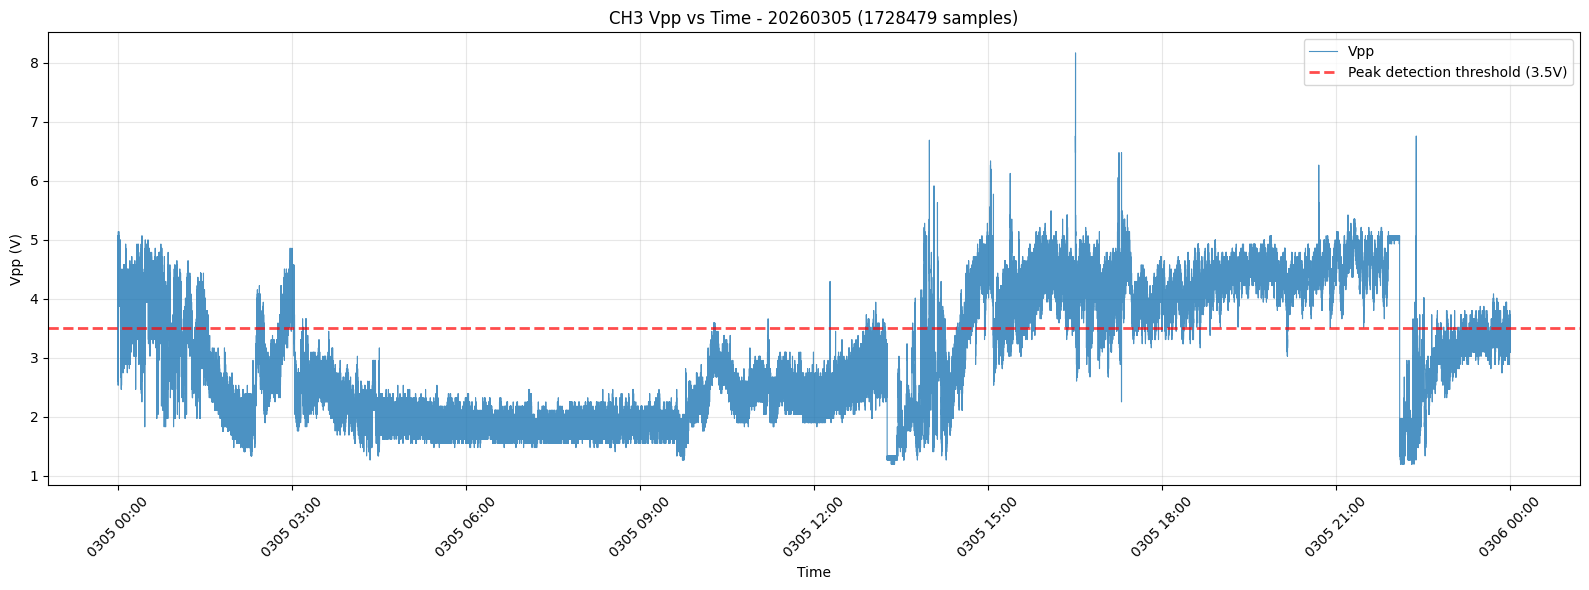

In [ ]:
# Get all subfolders in parent directory
subfolders = sorted([f.path for f in os.scandir(parent_folder) if f.is_dir()])
print(f"Found {len(subfolders)} folder(s) in: {parent_folder}")
print("="*60)

for folder_idx, video_folder in enumerate(subfolders):
    folder_name = os.path.basename(video_folder.rstrip('/'))
    print(f"\n{'='*60}")
    print(f"[{folder_idx + 1}/{len(subfolders)}] Processing folder: {folder_name}")
    print("="*60)
    
    # Find all .mkv files - try direct folder first
    mkv_files = sorted(glob.glob(os.path.join(video_folder, "*.mkv")))
    
    # If no files found, try RecData/0014 subdirectory
    if len(mkv_files) == 0:
        nested_folder = os.path.join(video_folder, "RecData", "0014")
        if os.path.isdir(nested_folder):
            mkv_files = sorted(glob.glob(os.path.join(nested_folder, "*.mkv")))
            if len(mkv_files) > 0:
                print(f"  → Found files in RecData/0014 subdirectory")
                video_folder = nested_folder
    
    print(f"Found {len(mkv_files)} total video file(s)")
    
    if len(mkv_files) == 0:
        print("  ⚠ No .mkv files found, skipping folder")
        continue
    
    # Create output folder based on video folder name
    output_folder = f"/Users/xylu/Desktop/Data/acoustic_vpp/{folder_name}"
    os.makedirs(output_folder, exist_ok=True)
    
    # Process files
    if max_files is None:
        mkv_files_to_process = mkv_files
        print(f"Processing all {len(mkv_files_to_process)} file(s)")
    else:
        mkv_files_to_process = mkv_files[:max_files]
        print(f"Processing {len(mkv_files_to_process)} file(s) (limited by max_files={max_files})")
    print("="*60)
    
    # Container for combined data
    all_time_datetime = []
    all_vpp_stored = []
    all_vpp_inj = []
    file_info = []
    
    for file_idx, file_path in enumerate(mkv_files_to_process):
        basename = os.path.basename(file_path)
        print(f"\n[{file_idx + 1}/{len(mkv_files_to_process)}] {basename}")
        
        # Extract start time
        start_dt = extract_datetime_from_filename(basename)
        if start_dt is None:
            print(f"  ⚠ Skipped: Could not extract datetime")
            continue
        
        # Compute Vpp series for both regions
        try:
            time_s, vpp_stored, vpp_inj = compute_vpp_series_for_file(
                file_path,
                v_div=v_div,
                fps=fps,
                threshold_stored=profile_threshold_stored,
                threshold_inj=profile_threshold_inj,
                split_x=inj_time_px,
                grid_height_px_stored=grid_height_px_stored,
                grid_height_px_inj=grid_height_px_inj,
            )
            
            # Convert time to datetime
            time_datetime_data = np.array([start_dt + timedelta(seconds=t) for t in time_s])
            
            # Accumulate data
            all_time_datetime.extend(time_datetime_data)
            all_vpp_stored.extend(vpp_stored)
            all_vpp_inj.extend(vpp_inj)
            
            # Create DataFrame for individual file
            df = pd.DataFrame({
                'time_datetime': time_datetime_data.astype(str),
                'time_seconds': time_s,
                'vpp_stored': vpp_stored,
                'vpp_inj': vpp_inj
            })
            
            # Save individual CSV
            csv_filename = basename.replace('.mkv', '_vpp.csv')
            csv_filepath = os.path.join(output_folder, csv_filename)
            df.to_csv(csv_filepath, index=False)
            
            vpp_stored_min, vpp_stored_max = np.nanmin(vpp_stored), np.nanmax(vpp_stored)
            vpp_inj_min, vpp_inj_max = np.nanmin(vpp_inj), np.nanmax(vpp_inj)
            print(f"  ✓ Vpp_stored: {vpp_stored_min:.3f} - {vpp_stored_max:.3f} V")
            print(f"  ✓ Vpp_inj: {vpp_inj_min:.3f} - {vpp_inj_max:.3f} V")
            file_info.append((basename, start_dt, vpp_stored_min, vpp_stored_max, vpp_inj_min, vpp_inj_max))
            
        except Exception as e:
            print(f"  ✗ Error: {str(e)}")
    
    # Convert to arrays
    all_time_datetime = np.array(all_time_datetime)
    all_vpp_stored = np.array(all_vpp_stored)
    all_vpp_inj = np.array(all_vpp_inj)
    
    print("\n" + "="*60)
    print(f"COMBINED DATA: {len(all_vpp_stored)} samples")
    if len(all_vpp_stored) > 0:
        print(f"Vpp_stored: {np.nanmin(all_vpp_stored):.3f} - {np.nanmax(all_vpp_stored):.3f} V")
        print(f"Vpp_inj: {np.nanmin(all_vpp_inj):.3f} - {np.nanmax(all_vpp_inj):.3f} V")
        print(f"Time span: {all_time_datetime[0]} to {all_time_datetime[-1]}")
    print("="*60)
    
    # Plot combined Vpp vs time
    if len(all_vpp_stored) > 0:
        fig, ax = plt.subplots(figsize=(16, 6))
        ax.plot(all_time_datetime, all_vpp_stored, linewidth=0.8, label='Vpp_stored', alpha=0.8)
        ax.plot(all_time_datetime, all_vpp_inj, linewidth=0.8, label='Vpp_inj', alpha=0.8)
        ax.axhline(y=peak_threshold, color='r', linestyle='--', linewidth=2, alpha=0.7, label=f'Peak detection threshold ({peak_threshold}V)')
        ax.set_title(f"CH3 Vpp vs Time - {folder_name} ({len(mkv_files_to_process)} files)")
        ax.set_xlabel("Time")
        ax.set_ylabel("Vpp (V)")
        ax.legend()
        ax.grid(True, alpha=0.3)
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%m%d %H:%M'))
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()
        
        # Find peaks in both signals
        vpp_peaks_stored, _ = find_peaks(all_vpp_stored, height=peak_threshold, distance=20)
        vpp_peaks_inj, _ = find_peaks(all_vpp_inj, height=peak_threshold, distance=20)
        print(f"\nFound {len(vpp_peaks_stored)} STORED peaks with Vpp > {peak_threshold} V")
        print(f"Found {len(vpp_peaks_inj)} INJ peaks with Vpp > {peak_threshold} V")
        print("="*60)
        
        # Save peak summaries and figure
        summary_folder = os.path.abspath(os.path.join(output_folder, '../summary/'))
        os.makedirs(summary_folder, exist_ok=True)
        
        # Create summary figure with both signals
        fig, ax = plt.subplots(figsize=(16, 6))
        ax.plot(all_time_datetime, all_vpp_stored, linewidth=0.8, label='Vpp_stored', alpha=0.8)
        ax.plot(all_time_datetime, all_vpp_inj, linewidth=0.8, label='Vpp_inj', alpha=0.8)
        ax.axhline(y=peak_threshold, color='r', linestyle='--', linewidth=2, alpha=0.7, label=f'Peak detection threshold ({peak_threshold}V)')
        ax.set_title(f"CH3 Vpp vs Time - {folder_name} ({len(all_vpp_stored)} samples)")
        ax.set_xlabel("Time")
        ax.set_ylabel("Vpp (V)")
        ax.legend()
        ax.grid(True, alpha=0.3)
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%m%d %H:%M'))
        plt.xticks(rotation=45)
        plt.tight_layout()
        plot_path = os.path.join(summary_folder, f"{folder_name}_peak_summary_plot.png")
        plt.savefig(plot_path, dpi=100, bbox_inches='tight')
        plt.show()
        print(f"✓ Peak summary plot saved to: {plot_path}")
        
        # Save STORED peaks
        if len(vpp_peaks_stored) > 0:
            stored_peak_data = []
            for peak_idx, sample_idx in enumerate(vpp_peaks_stored):
                peak_time = all_time_datetime[sample_idx]
                vpp_stored_val = all_vpp_stored[sample_idx]
                vpp_inj_val = all_vpp_inj[sample_idx]
                stored_peak_data.append({
                    'peak_number': peak_idx + 1,
                    'sample_idx': int(sample_idx),
                    'time_datetime': peak_time.strftime('%Y-%m-%d %H:%M:%S.%f')[:-3],
                    'vpp_stored_volts': float(vpp_stored_val),
                    'vpp_inj_volts': float(vpp_inj_val)
                })
            stored_df = pd.DataFrame(stored_peak_data)
            stored_csv_path = os.path.join(summary_folder, f"{folder_name}_peaks_stored.csv")
            stored_df.to_csv(stored_csv_path, index=False)
            print(f"✓ Stored peaks saved to: {stored_csv_path}")
        
        # Save INJ peaks
        if len(vpp_peaks_inj) > 0:
            inj_peak_data = []
            for peak_idx, sample_idx in enumerate(vpp_peaks_inj):
                peak_time = all_time_datetime[sample_idx]
                vpp_stored_val = all_vpp_stored[sample_idx]
                vpp_inj_val = all_vpp_inj[sample_idx]
                inj_peak_data.append({
                    'peak_number': peak_idx + 1,
                    'sample_idx': int(sample_idx),
                    'time_datetime': peak_time.strftime('%Y-%m-%d %H:%M:%S.%f')[:-3],
                    'vpp_inj_volts': float(vpp_inj_val),
                    'vpp_stored_volts': float(vpp_stored_val)
                })
            inj_df = pd.DataFrame(inj_peak_data)
            inj_csv_path = os.path.join(summary_folder, f"{folder_name}_peaks_inj.csv")
            inj_df.to_csv(inj_csv_path, index=False)
            print(f"✓ Inj peaks saved to: {inj_csv_path}")
    
    print(f"\n✓ Folder '{folder_name}' complete! Data saved to: {output_folder}")

print("\n" + "="*60)
print("ALL FOLDERS PROCESSED!")
print("="*60)